# System 9: $V(r) = -10e^{-r^2}+0.8755e^{-(r-3)^2/1.5^2}$, $s$-wave bound state, narrow $p$-wave resonance.
- Supports an $s$-wave bound state at $E_b=-2.40706272$.
- Supports a $p$-wave resonance at $E_r=0.81592338 - i0.04959887 $
    - $\phi_\text{min}=\text{arg}(E) / 2 \approx 0.030357$.
    - $V(r)$ is a Gaussian, so $\phi_\text{max}=\pi/4\approx0.785$
- $\phi_\text{min} \le \phi < \phi_\text{max} = 0.064960 \le \phi < 0.785$.
- By $r=10$, $V(r=10)\propto 10^{-10} \approx 0$.

Due to finite volume effects, the good region of $\phi$ might vary from its theoretical value. This is a very narrow resonance. This gives
EC a much larger region to train over and a much smaller gap to extrapolate across for back-rotation.

In [1]:
from src.dvr import DVR
from src.ec import ECSystem
from src.ecensemble import ECEnsemble

from src.utils.sweep_utils import *
from src.utils.print_plot_utils import *
from src.utils.reference_utils import *
from src.utils.ec_utils import *
from src.utils.ensemble_utils import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
system_num = 9

mesh_width_guess = 0.15
L_guess = 50.0
n_guess = max(L_guess // mesh_width_guess - 1, 1)
phi_guess = 0.5

res_guess = 0.81592338 - 1j*0.04959887  # expected value of resonance
bound_guess = -2.40706272 + 1j*0.0   # due to finite volume, there will be a small imaginary component from CSM
telem_guess = 0.88767295 - 1j*0.076656155
rr_guess = 0.74496945 + 1j*0.37551095

V_0, R = 10.0, 1.0
r_b, w, V_b = 3.0, 1.5, 0.8755102
def gauss_barrier(r):
    att_gauss = -V_0 * np.exp(-r**2/R**2)
    extra_barr = V_b * np.exp(-(r-r_b)**2/w**2)
    return att_gauss + extra_barr

In [3]:
sbound_system = DVR(n_guess, L_guess, rotation_angle=0.0, potential=gauss_barrier, l=0)
pres_system = DVR(n_guess, L_guess, rotation_angle=phi_guess, potential=gauss_barrier, l=1)

In [4]:
save_plots = True
plots_folder = get_plots_path() / f"system_{system_num}_complexphi"
plots_folder.mkdir(exist_ok=True, parents=True)

### $E(L)$, $(r_\theta^2)(L)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $\phi$.

In [5]:
# compute <r^2> as L varies
dvr_observables = {"energies": obs_energy, "rrs": obs_rr, "telems": obs_telem}

Ls = np.linspace(20.0, 70., 20)
results = linesweep_L(
    phi_guess,
    res_guess,
    Ls,
    mesh_width_guess,
    dvr_observables,
    resonance_potential=gauss_barrier,
    resonance_l=1,
    bound_energy=bound_guess,
    bound_potential=gauss_barrier,
    bound_l=0
)
energies = results["energies"]
rrs = results["rrs"]
telems = results["telems"]
ns = results["ns"]
actual_mesh_widths = results["actual_mesh_widths"]

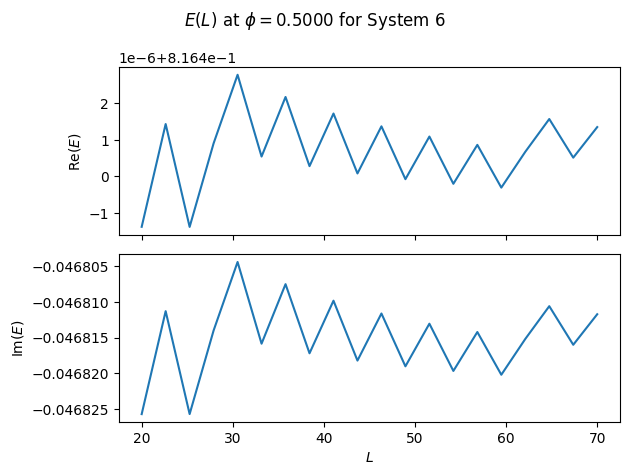

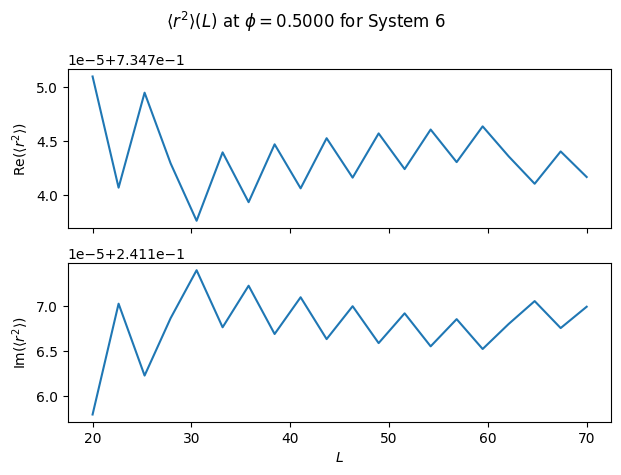

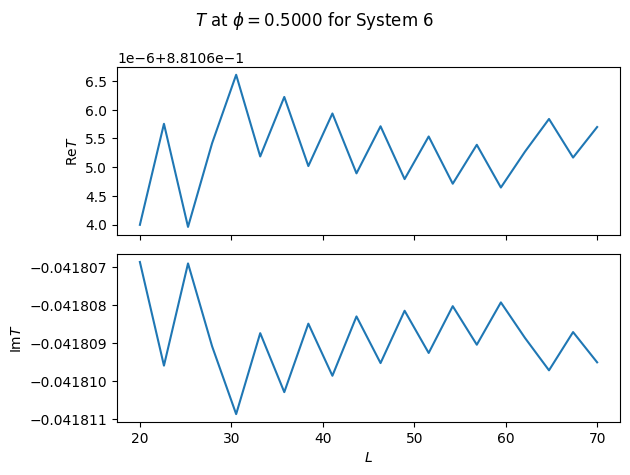

In [6]:
# plot E(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(energies))
ax2.plot(Ls, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$E(L)$ at $\phi=${phi_guess:.4f} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_L")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs))
ax2.plot(Ls, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$\langle r^2\rangle(L)$ at $\phi=${phi_guess:.4f} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_L.png")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(telems))
ax2.plot(Ls, np.imag(telems))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $\phi=${phi_guess:.4f} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_L.png")
plt.show()

In [7]:
# Best (L, n) so far
mesh_width_best = 0.15
L_best = 50.0
n_best = max(L_best // mesh_width_best - 1, 1)
pres_system = DVR(n_best, L_best, phi_guess, potential=gauss_barrier, l=1)
sbound_system = DVR(n_best, L_best, phi_guess, potential=gauss_barrier, l=0)

### $E(\phi)$, $(r^2)(\theta)$, $(\psi_\text{res}|r|\psi_\text{bound})$ at fixed $L$ (real $\phi$).

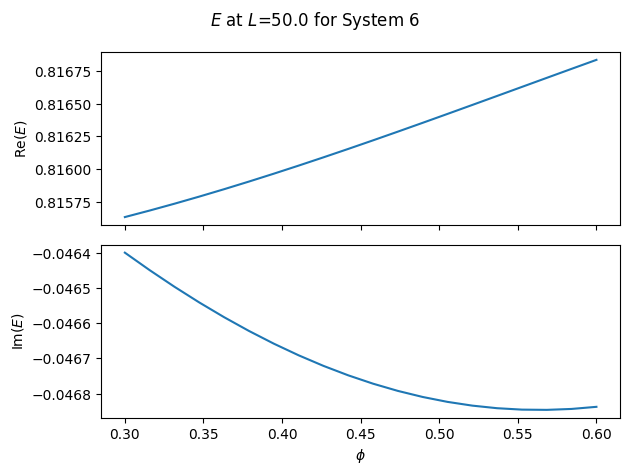

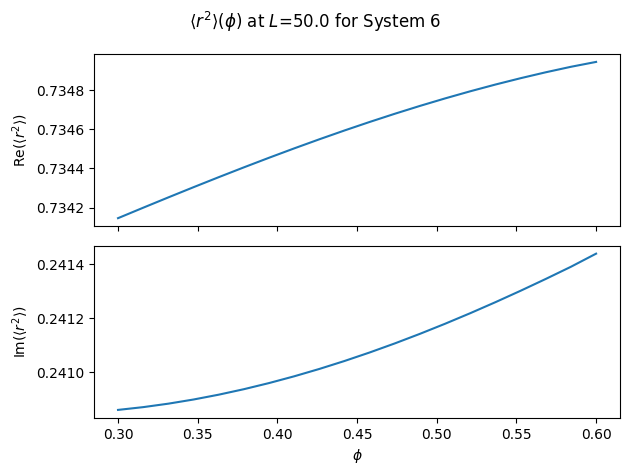

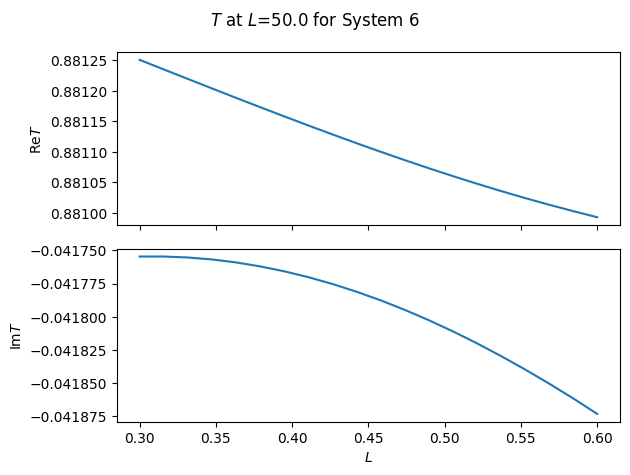

In [8]:
# compute E and <r^2> as phi varies
# the ABC theorem says that this should be const.
phi_scan = 20
phi_lo, phi_hi = 0.3, 0.6 #get_phi_bounds(res_guess)
phis = np.linspace(phi_lo, phi_hi, phi_scan)

results = linesweep_phi(
    pres_system,
    res_guess,
    phis,
    dvr_observables,
    sbound_system,
    bound_guess
)
energies, rrs, telems = results["energies"], results["rrs"], results["telems"]   

# plot <E>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies))
ax2.plot(phis, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(rf"$E$ at $L$={L_guess} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "E_stability_phi.png")
plt.show()

# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs))
ax2.plot(phis, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(rf"$\langle r^2\rangle(\phi)$ at $L$={L_guess} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "rr_stability_phi.png")
plt.show()

# plot transition matrix elements
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(telems))
ax2.plot(phis, np.imag(telems))
ax1.set_ylabel(r"Re$T$")
ax2.set_ylabel(r"Im$T$")
ax2.set_xlabel(r"$L$")
fig.suptitle(rf"$T$ at $L$={L_guess} for System 6")
plt.tight_layout()
if save_plots: plt.savefig(plots_folder / "telem_stability_phi.png")
plt.show()

### Get training data over $\Re(\phi)$ and use that to compute references

In [9]:
# best Re(phi) range so far
phi_real_range = [0.2, 0.6]
phi_best = np.mean(phi_real_range)

In [10]:
npoints = 100
phi_real_ref = np.linspace(phi_real_range[0], phi_real_range[1], npoints)
reference_results = linesweep_phi(
    pres_system,
    res_guess,
    phi_real_ref,
    dvr_observables,
    sbound_system,
    bound_guess
)
print_training_data(reference_results)
real_res = get_reference(reference_results["energies"], tol=1e-3) 
real_rr = get_reference(reference_results["rrs"], tol=1e-2)
real_telem = get_reference(reference_results["telems"], tol=1e-3)
real_bound = get_reference(reference_results["bound_energies"], tol=1e-3)

Training energies: (0.81599 +- 0.00044) + i(-0.04667 +- 0.00025)
Training rrs: (0.73447 +- 0.00035) + i(0.24097 +- 0.00019)
Training telems: (0.88115 +- 0.00011) + i(-0.04177 +- 0.00003)
Training bound_energies: (-2.40707 +- 0.00000) + i(0.00000 +- 0.00000)


### Extend $\phi$ to the complex plane and analyze plateau regions using DVR

In [11]:
phis_real = np.linspace(phi_real_range[0], phi_real_range[1], 5)
phis_imag = np.linspace(-.2, 0.4, 5)

results = gridsweep_phi(
    pres_system,
    real_res,
    phis_real,
    phis_imag,
    dvr_observables,
    sbound_system,
    real_bound
)
energies_resid = residual(real_res, results["energies"])
rrs_resid = residual(real_rr, results["rrs"])
telems_resid = residual(real_telem, results["telems"])
benergies_resid = residual(real_bound, results["bound_energies"])

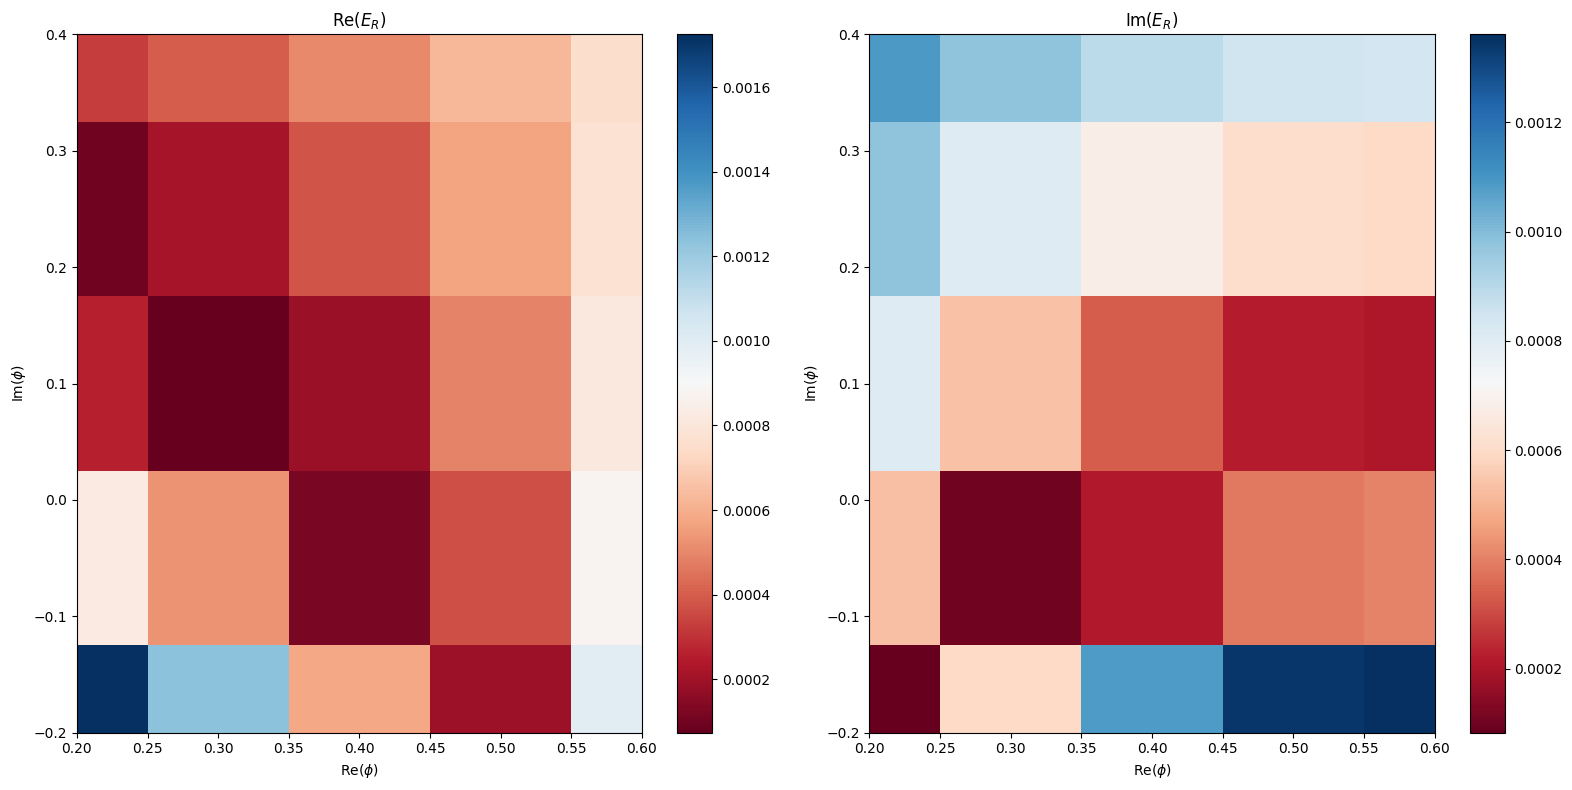

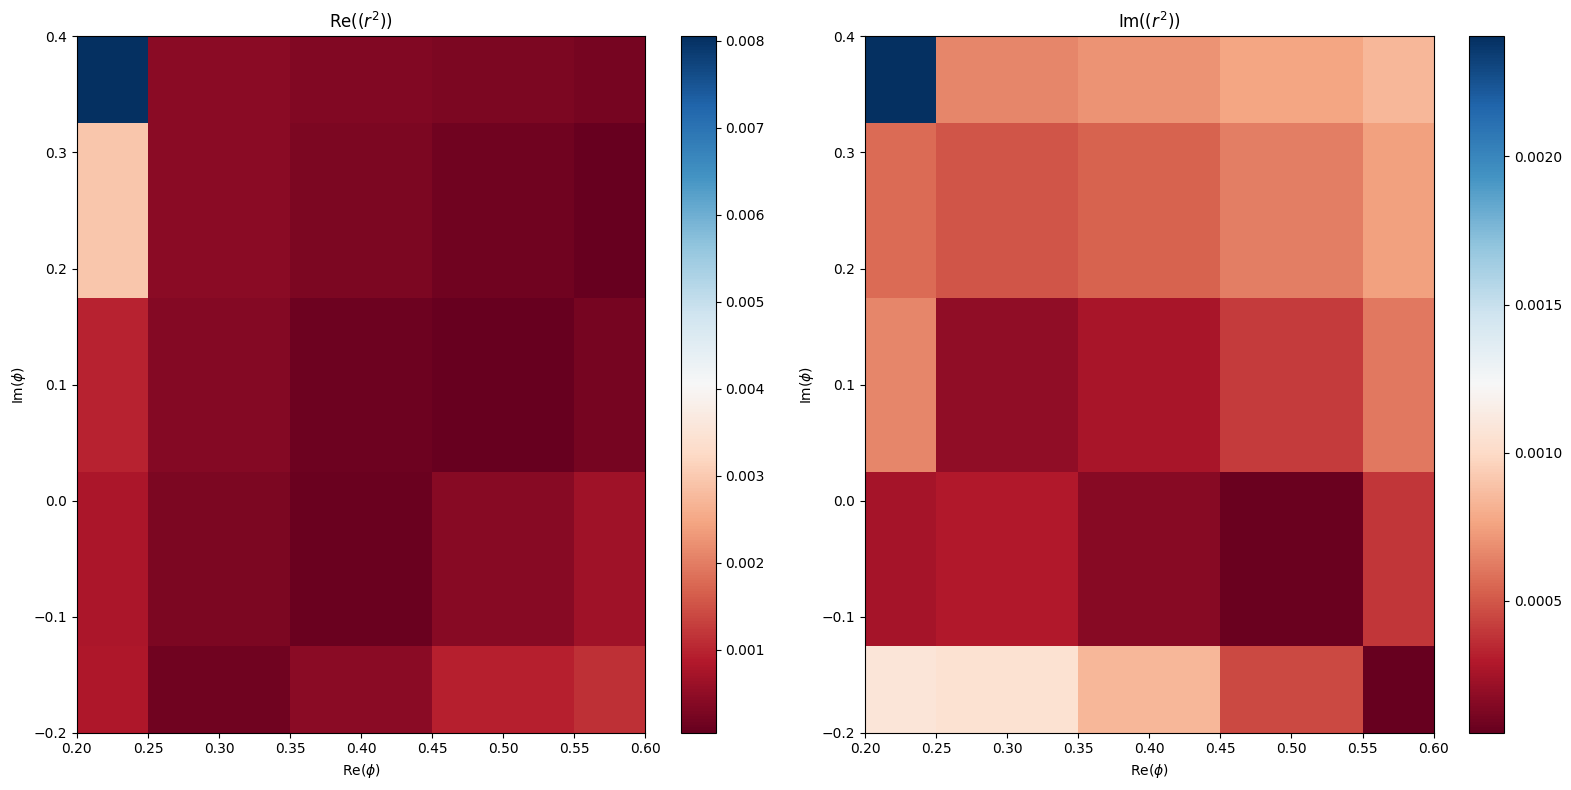

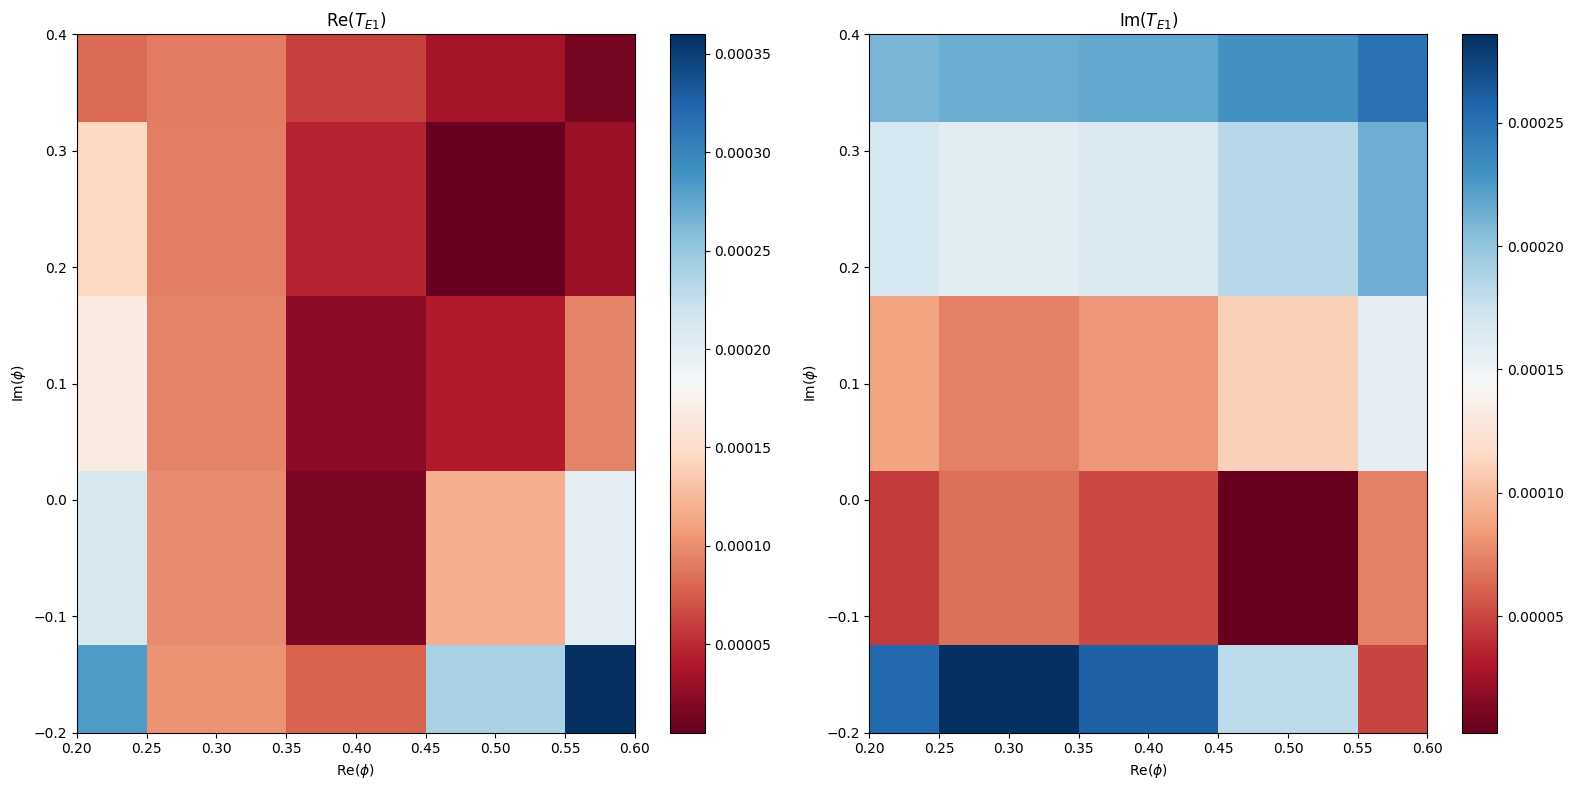

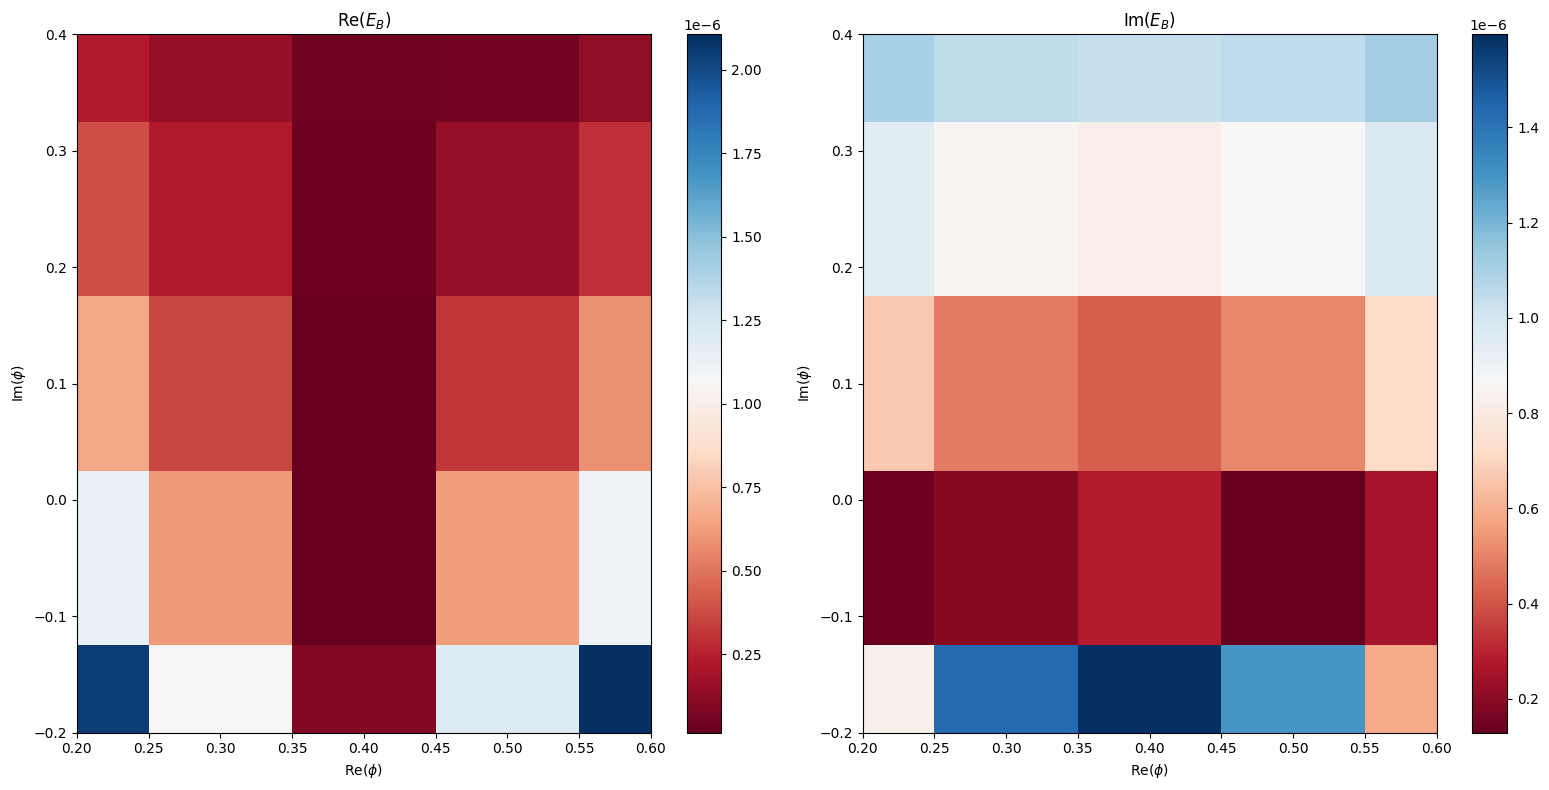

In [12]:
# energy plot
figsize = (16,8)
plot_data_over_phi_grid(phis_real, phis_imag, energies_resid, title=r'$E_R$', figsize=figsize)
plt.show()

# rr plot
plot_data_over_phi_grid(phis_real, phis_imag, rrs_resid, title=r'$(r^2)$', figsize=figsize)
plt.show()

# telem plot
plot_data_over_phi_grid(phis_real, phis_imag, telems_resid, title=r'$T_{E1}$', figsize=figsize)
plt.show()

# real bound state energy plot
plot_data_over_phi_grid(phis_real, phis_imag, benergies_resid, title=r'$E_B$', figsize=figsize)
plt.show()

#### Nudge mesh width to see if it stays converged
We do this because continuing $\theta$ to the complex plane induces a radial dilation, which is sensitive to finite volume effects. If a converged plot suddenly isn't converged after nudging the mesh width, then it wasn't physically converged. If we make our mesh finer, and nothing changes, we're probably near the limit. 

Current best mesh width: w=0.1500. (n, L)=(332.0, 50.0).
Nudged mesh width: w=0.1202. (n, L)=(415.0, 50.0).


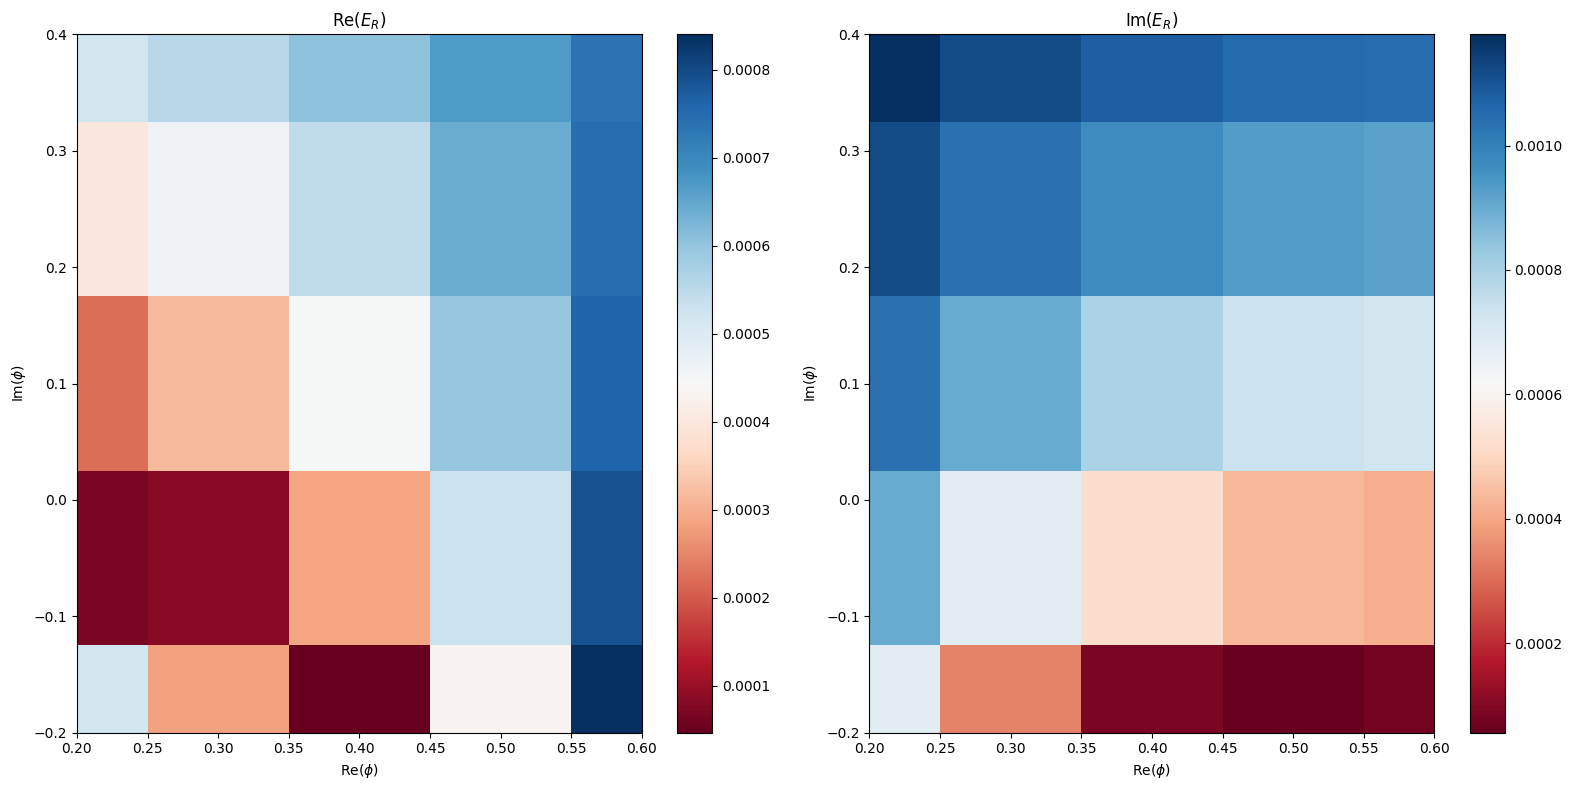

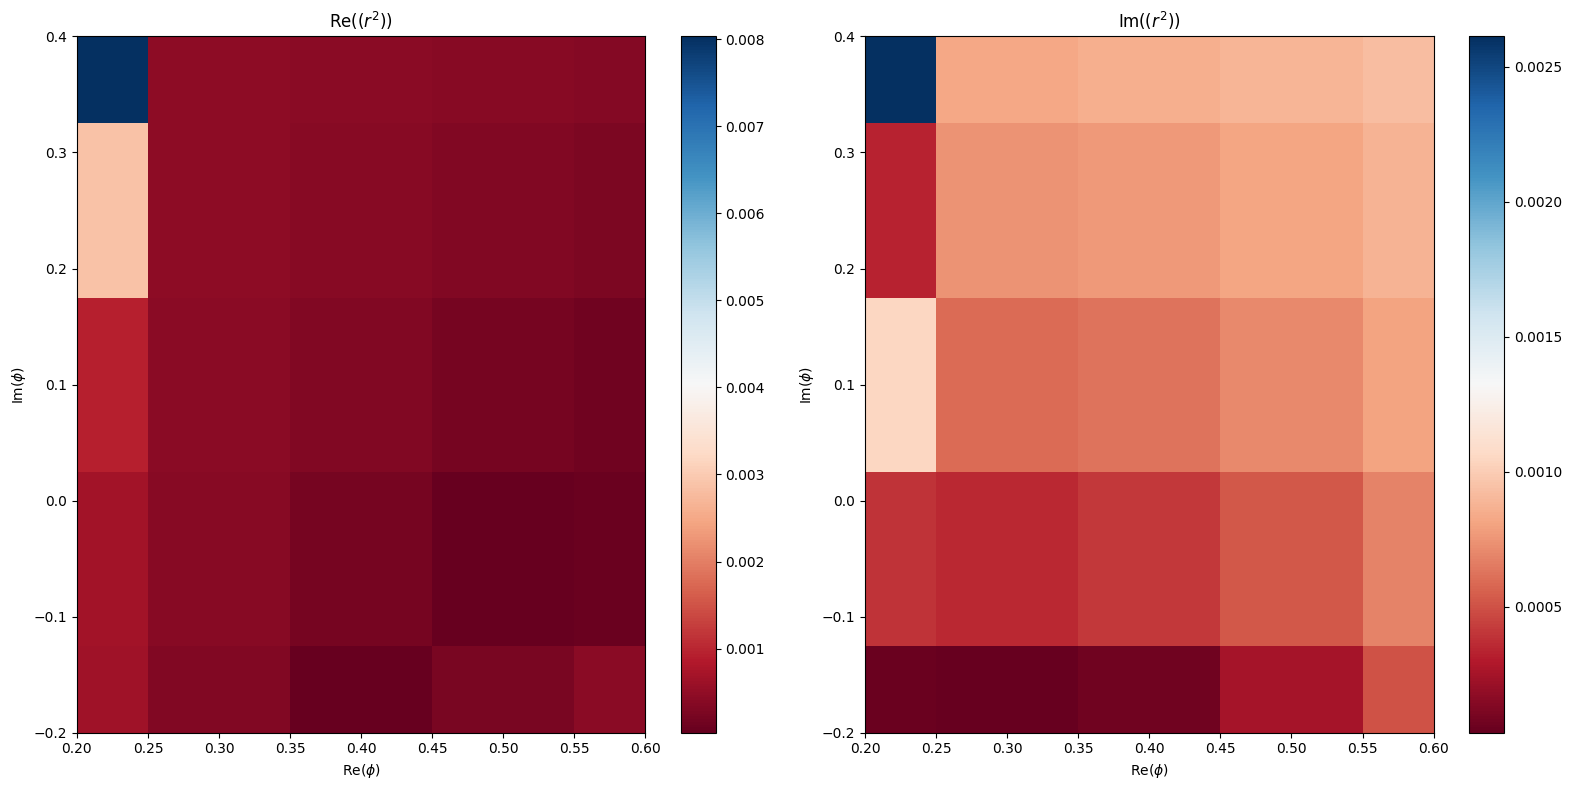

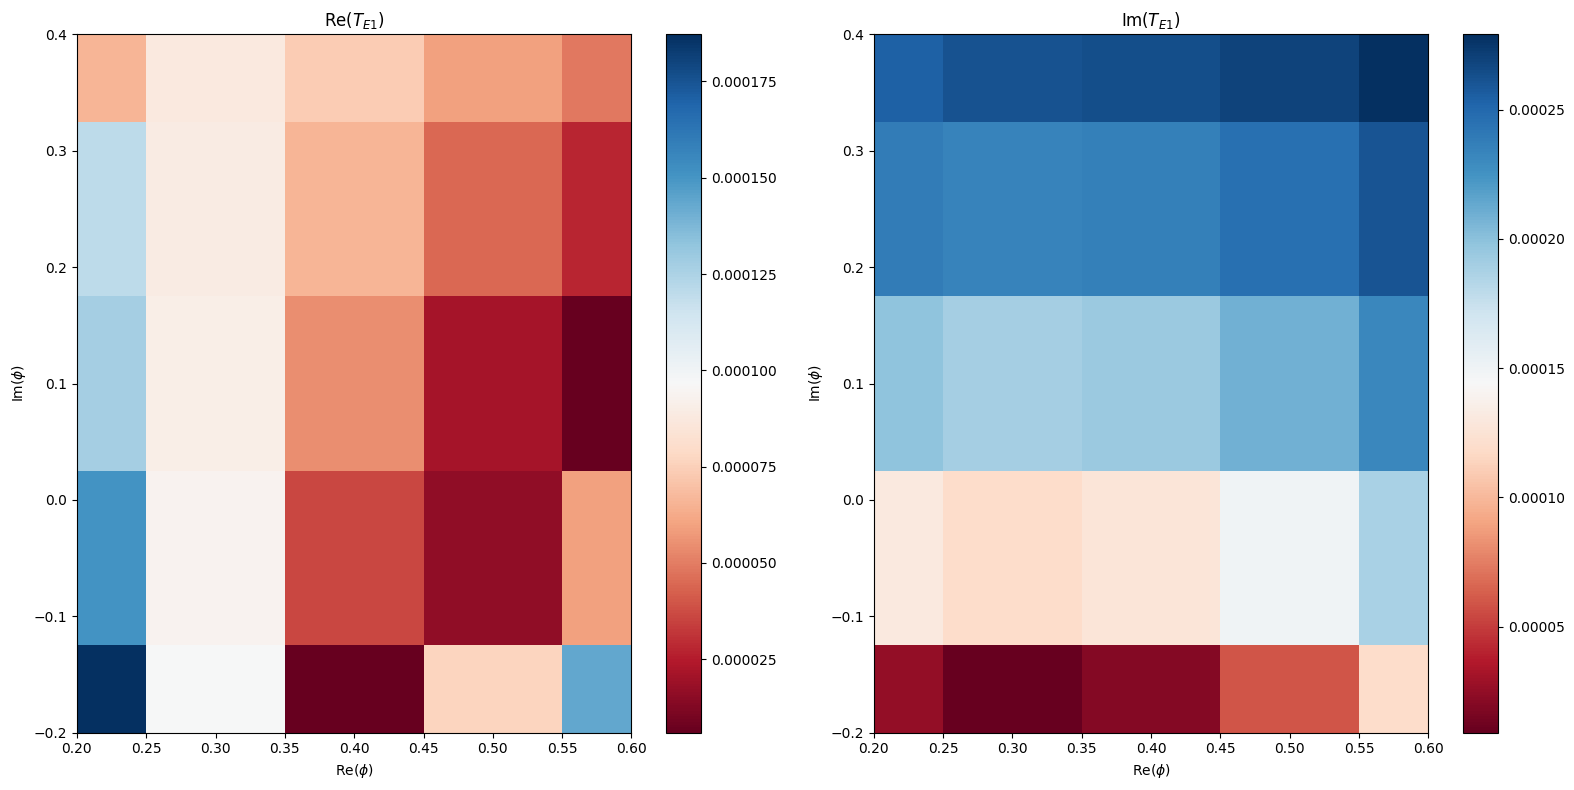

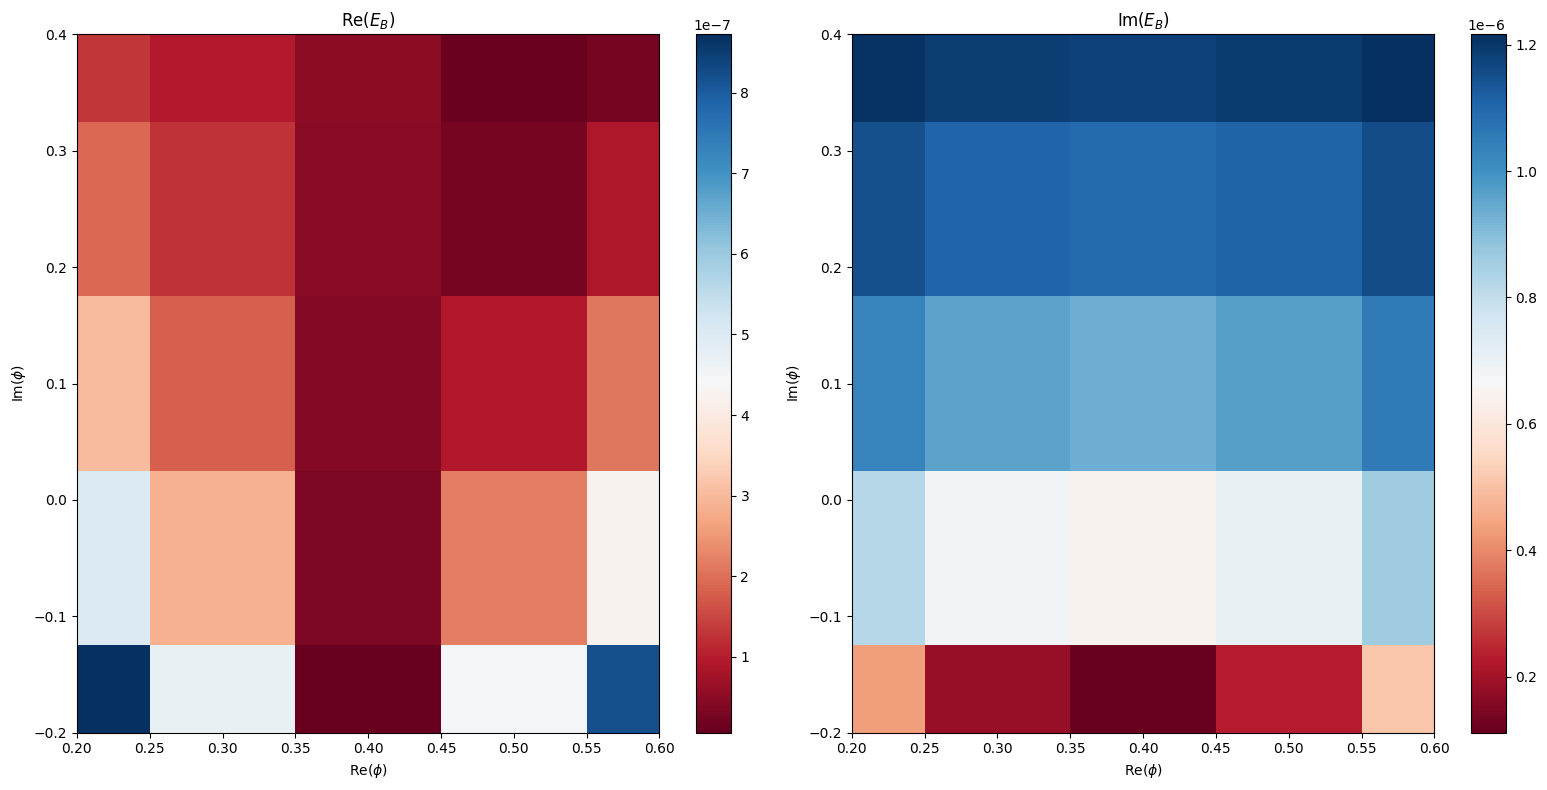

In [13]:
current_mesh_width = mesh_width_best
print(f"Current best mesh width: w={current_mesh_width:.4f}. (n, L)=({n_best}, {L_best}).")

mesh_width_test = 0.8 * current_mesh_width
n_test = max(L_best // mesh_width_test - 1, 1)
print(f"Nudged mesh width: w={L_best / (n_test + 1):.4f}. (n, L)=({n_test}, {L_best}).")

sbound_test = DVR(n_test, L_best, rotation_angle=0.0, potential=gauss_barrier, l=0)
pres_test = DVR(n_test, L_best, rotation_angle=phi_best, potential=gauss_barrier, l=1)

results = gridsweep_phi(
    pres_test,
    real_res,
    phis_real,
    phis_imag,
    dvr_observables,
    sbound_test,
    real_bound
)
energies_resid = residual(real_res, results["energies"])
rrs_resid = residual(real_rr, results["rrs"])
telems_resid = residual(real_telem, results["telems"])
benergies_resid = residual(real_bound, results["bound_energies"])

# energy plot
figsize = (16,8)
plot_data_over_phi_grid(phis_real, phis_imag, energies_resid, title=r'$E_R$', figsize=figsize)
plt.show()

# rr plot
plot_data_over_phi_grid(phis_real, phis_imag, rrs_resid, title=r'$(r^2)$', figsize=figsize)
plt.show()

# telem plot
plot_data_over_phi_grid(phis_real, phis_imag, telems_resid, title=r'$T_{E1}$', figsize=figsize)
plt.show()

# real bound state energy plot
plot_data_over_phi_grid(phis_real, phis_imag, benergies_resid, title=r'$E_B$', figsize=figsize)
plt.show()

In [14]:
phi_imag_range = [-0.2, 0.4]

### Automate search for best $(L, $mesh width$,\phi)$

In [15]:
# automate search for best L, n (mesh width) (scans over observables looking for plateaus).
# - run search_mesh_width over a suitable range of mesh widths for a few values of L (this gets expensive if L is large and mesh width is too small)
# - pick the best mesh width from the batch
# - run search_L at the winning mesh width for a suitable range of L
# - pick the winning L. This gives L_best, n_best
### L_best, n_best = 50.0, 256
###pres_system = DVR(n_best, L_best, phi_best, potential=gauss_barrier, l=1)
###sbound_system = DVR(n_best, L_best, phi_best, potential=gauss_barrier, l=0)

# using the new DVR guess, find the best range for training Re(phi)
# - run search_optimal_phirange to find the best range for Re(phi)
###phi_best = 0.35
###phi_real_range = [0.31, 0.47]

# using the winning real phis, scan over the imaginary component to find the best range for training Im(phi)
# - this isn't implemented in sweep_utils.py yet.
###phi_imag_range = [-0.2, 0.4]

# NOTE: CURRENTLY MANUALLY SWEEPING THROUGH TO FIND PLATEAUS BECAUSE MY AUTOMATION CODE NEEDS SOME FINE TUNING BEFORE IT 
# CAN FIND PLATEAUS AS WELL AS A PERSON CAN MANUALLY

### Train EC on complex $\theta$.

In [16]:
# get real training set
num_real_training_points = 25
phi_real_train = np.linspace(phi_real_range[0], phi_real_range[1], num_real_training_points, dtype=np.complex128)

# get complex training set
nreal, nimag = 5, 5
phir = np.linspace(phi_real_range[0], phi_real_range[1], nreal)
phii = np.linspace(phi_imag_range[0], phi_imag_range[1], nimag)

phi_complex_train = []
for pr in phir:
    for pii in phii:
        phi_complex_train.append(pr + 1j*pii)
phi_complex_train = np.asarray(phi_complex_train, dtype=np.complex128)

# full training set
phi_train = np.concatenate((phi_real_train, phi_complex_train))

In [17]:
# train on complex rotation angles
pres_system.reset_rotation_angle(phi_best)
sbound_system.reset_rotation_angle(phi_best) 
ec_system = ECSystem(pres_system, real_res)

ec_system.train(phi_train)
ec_system.construct_basis()

print(
    f"EC trained on {num_real_training_points+(nimag*nreal)} total training points.\n"
    f"{num_real_training_points} of the training points are pure real in [{phi_real_range[0]:.5f}, {phi_real_range[1]:.5f}].\n"
    f"{nimag*nreal} training points are complex: real resolution (Re(phi range), num real) = ([{phi_real_range[0]:.5f}, {phi_real_range[1]:.5f}], {nreal})\n"
    f"imaginary resolution (Im(phi range), num imag) = ([{phi_imag_range[0]:.5f}, {phi_imag_range[1]:.5f}], {nimag})\n"
)

EC trained on 50 total training points.
25 of the training points are pure real in [0.20000, 0.60000].
25 training points are complex: real resolution (Re(phi range), num real) = ([0.20000, 0.60000], 5)
imaginary resolution (Im(phi range), num imag) = ([-0.20000, 0.40000], 5)



### Predictions

#### Interpolation to $\phi$ in the good region

In [18]:
phi_predict = phi_best

observables = {"energy": predict_energy, "rr": predict_rr, "telem": predict_telem}
references = {"energy": real_res, "rr" : real_rr, "telem": real_telem}
results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)
print(f"-----------------------------------\n Results (Interpolation to phi={phi_predict.real:.3f}+i{phi_predict.imag:.3f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Interpolation to phi=0.400+i0.000) 
 ----------------------------------
energy:0.81599 + i-0.04667
rr:0.73448 + i0.24096
telem:0.88115 + i-0.04177
-----------------------------------
 Residuals 
 ------------------------
energy:0.00000 + i0.00000
rr:0.00001 + i0.00000
telem:0.00000 + i0.00000
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00000 + i-0.00000
rr:0.00001 + i0.00002
telem:0.00000 + i-0.00004


#### Extrapolation to $\phi=0.0$

In [19]:
phi_predict = 0.0

results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)
print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Extrapolation to phi=0.0000) 
 ----------------------------------
energy:0.81647 + i-0.04586
rr:0.74982 + i-0.05264
telem:0.87720 + i-0.03610
-----------------------------------
 Residuals 
 ------------------------
energy:0.00049 + i0.00081
rr:0.01535 + i0.29361
telem:0.00395 + i0.00566
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00060 + i-0.01735
rr:0.02090 + i1.21846
telem:0.00448 + i-0.13560


#### Compare to performance when trained on just real values

In [20]:
# train on purely real rotation angles
pres_system.reset_rotation_angle(phi_best)
sbound_system.reset_rotation_angle(phi_best)
ec_system = ECSystem(pres_system, real_res)

# get training data
numt = num_real_training_points + nimag*nreal # train on the total number of training points from before
phi_train = np.linspace(phi_real_range[0], phi_real_range[1], numt, dtype=np.complex128)

ec_system.train(phi_train)
ec_system.construct_basis()

In [21]:
phi_predict = phi_best # np.median(np.real(phi_train)) + 1j*np.median(np.imag(phi_train))

results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)
print(f"-----------------------------------\n Results (Interpolation to phi={phi_predict.real:.3f}+i{phi_predict.imag:.3f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Interpolation to phi=0.400+i0.000) 
 ----------------------------------
energy:0.81599 + i-0.04667
rr:0.73446 + i0.24096
telem:0.88115 + i-0.04177
-----------------------------------
 Residuals 
 ------------------------
energy:0.00000 + i0.00000
rr:0.00001 + i0.00000
telem:0.00000 + i0.00000
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00000 + i-0.00000
rr:0.00001 + i0.00001
telem:0.00000 + i-0.00001


In [22]:
phi_predict = 0.0

results = quick_predict(
    ec_system,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)
print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) \n ----------------------------------")
print_quick_predict(results)
print("-----------------------------------\n Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results))
print("-----------------------------------\n Relative Residuals \n ------------------------")
print_quick_predict(quick_residuals(references, results, relative=True))

-----------------------------------
 Results (Extrapolation to phi=0.0000) 
 ----------------------------------
energy:0.81534 + i-0.04545
rr:0.02704 + i-0.55720
telem:0.88354 + i-0.03889
-----------------------------------
 Residuals 
 ------------------------
energy:0.00065 + i0.00122
rr:0.70743 + i0.79817
telem:0.00239 + i0.00288
-----------------------------------
 Relative Residuals 
 ------------------------
energy:0.00079 + i-0.02606
rr:0.96318 + i3.31237
telem:0.00271 + i-0.06895


### Run ensemble over training region

In [28]:
# set up
necsystems = 128
ecensemble_tensor = ECEnsemble(necsystems, pres_system, real_res)
ecensemble_lhc = ECEnsemble(necsystems, pres_system, real_res)

# train
num_real = 25
num_complex = 25
nr, ni = 5, 5
seed = 1341
ecensemble_tensor.train(phi_real_range, num_real, phi_imag_range, phi_grid_points=[nr, ni], seed=seed)
ecensemble_lhc.train(phi_real_range, num_real, phi_imag_range, phi_complex_points=num_complex, seed=seed)

In [29]:
# construct bases
ecensemble_tensor.construct_bases()
ecensemble_lhc.construct_bases()

In [30]:
# predict
phi_predict = 0.0
observables = {"energies": ensemble_energies, "rrs": ensemble_rrs, "telems": ensemble_telems}
reference = {"energies": real_res, "rrs": real_rr, "telems": real_telem}
results = quick_predict_ensemble(
    ecensemble_tensor,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)

print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) Tensor \n ----------------------------------")
rstats = quick_stats(results)
print_quick_predict_ensemblestats(rstats)
print("-----------------------------------\n Residuals \n ------------------------")
rstats = quick_stats(results, reference)
print_quick_predict_ensemblestats(rstats)
print("-----------------------------------\n Relative Residuals \n ------------------------")
rstats = quick_stats(results, reference, relative=True)
print_quick_predict_ensemblestats(rstats)

-----------------------------------
 Results (Extrapolation to phi=0.0000) Tensor 
 ----------------------------------
energies: Median: 0.81520 + i-0.04546. 68%: [0.81442, 0.81581] + i[-0.04614, -0.04472]. 95%: [0.81157, 0.81739] + i[-0.04821, -0.04236].
rrs: Median: 0.65895 + i0.28244. 68%: [-0.00479, 1.27523] + i[-0.19459, 0.85251]. 95%: [-4.01707, 12.52964] + i[-7.63456, 4.95462].
telems: Median: 0.88166 + i-0.04104. 68%: [0.87675, 0.88491] + i[-0.04353, -0.03554]. 95%: [0.86269, 0.89610] + i[-0.05679, -0.02027].
-----------------------------------
 Residuals 
 ------------------------
energies: Median: 0.00085 + i0.00130. 68%: [0.00036, 0.00165] + i[0.00078, 0.00207]. 95%: [0.00011, 0.00565] + i[0.00013, 0.00431].
rrs: Median: 0.35490 + i0.26755. 68%: [0.08819, 1.23869] + i[0.06723, 1.05291]. 95%: [0.02859, 11.79517] + i[0.00736, 16.33864].
telems: Median: 0.00232 + i0.00186. 68%: [0.00077, 0.00712] + i[0.00048, 0.00782]. 95%: [0.00009, 0.01959] + i[0.00015, 0.04291].
------------

In [31]:
results = quick_predict_ensemble(
    ecensemble_lhc,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)

print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) LHC \n ----------------------------------")
rstats = quick_stats(results)
print_quick_predict_ensemblestats(rstats)
print("-----------------------------------\n Residuals \n ------------------------")
rstats = quick_stats(results, reference)
print_quick_predict_ensemblestats(rstats)
print("-----------------------------------\n Relative Residuals \n ------------------------")
rstats = quick_stats(results, reference, relative=True)
print_quick_predict_ensemblestats(rstats)

-----------------------------------
 Results (Extrapolation to phi=0.0000) LHC 
 ----------------------------------
energies: Median: 0.81549 + i-0.04492. 68%: [0.81332, 0.81734] + i[-0.04688, -0.04288]. 95%: [0.80978, 0.82022] + i[-0.04979, -0.03923].
rrs: Median: 0.82984 + i-0.03807. 68%: [-1.88316, 3.22747] + i[-2.10553, 1.68825]. 95%: [-11.48195, 13.47795] + i[-22.42860, 6.50266].
telems: Median: 0.88249 + i-0.04027. 68%: [0.87403, 0.89324] + i[-0.04850, -0.03112]. 95%: [0.85807, 0.92655] + i[-0.06244, 0.00646].
-----------------------------------
 Residuals 
 ------------------------
energies: Median: 0.00129 + i0.00211. 68%: [0.00040, 0.00348] + i[0.00049, 0.00385]. 95%: [0.00010, 0.00808] + i[0.00010, 0.00744].
rrs: Median: 1.29843 + i1.11512. 68%: [0.28402, 4.50603] + i[0.34579, 3.31332]. 95%: [0.04812, 18.27114] + i[0.06287, 38.22180].
telems: Median: 0.00558 + i0.00536. 68%: [0.00180, 0.01973] + i[0.00143, 0.01610]. 95%: [0.00037, 0.04632] + i[0.00028, 0.05719].
-------------

#### Compare to training over just reals

In [32]:
# set up
ecensemble_reals = ECEnsemble(necsystems, pres_system, real_res)

# train
n = num_real + num_complex
ecensemble_reals.train(phi_real_range, n, seed=seed)
ecensemble_reals.construct_bases()

results = quick_predict_ensemble(
    ecensemble_reals,
    phi_predict,
    observables,
    pres_system,
    real_res,
    sbound_system,
    real_bound
)

print(f"-----------------------------------\n Results (Extrapolation to phi={phi_predict:.4f}) Tensor \n ----------------------------------")
rstats = quick_stats(results)
print_quick_predict_ensemblestats(rstats)
print("-----------------------------------\n Residuals \n ------------------------")
rstats = quick_stats(results, reference)
print_quick_predict_ensemblestats(rstats)
print("-----------------------------------\n Relative Residuals \n ------------------------")
rstats = quick_stats(results, reference, relative=True)
print_quick_predict_ensemblestats(rstats)

-----------------------------------
 Results (Extrapolation to phi=0.0000) Tensor 
 ----------------------------------
energies: Median: 0.81508 + i-0.04525. 68%: [0.81492, 0.81523] + i[-0.04539, -0.04503]. 95%: [0.81473, 0.81538] + i[-0.04546, -0.04479].
rrs: Median: 0.27919 + i0.13182. 68%: [0.07314, 0.60174] + i[-0.21451, 0.29544]. 95%: [-0.10266, 0.76245] + i[-0.51945, 0.31394].
telems: Median: 0.88143 + i-0.03953. 68%: [0.87970, 0.88289] + i[-0.03976, -0.03914]. 95%: [0.87837, 0.88353] + i[-0.04001, -0.03825].
-----------------------------------
 Residuals 
 ------------------------
energies: Median: 0.00090 + i0.00142. 68%: [0.00075, 0.00106] + i[0.00128, 0.00164]. 95%: [0.00061, 0.00126] + i[0.00121, 0.00188].
rrs: Median: 0.45528 + i0.10915. 68%: [0.13273, 0.66133] + i[0.03694, 0.45547]. 95%: [0.00651, 0.83713] + i[0.00762, 0.76042].
telems: Median: 0.00112 + i0.00224. 68%: [0.00044, 0.00210] + i[0.00201, 0.00263]. 95%: [0.00006, 0.00291] + i[0.00176, 0.00352].
----------------